# **Group5 Assignment: Information Based Learning Models Implementation**


**Members:**
* Ablanque, Alex Jr.
* Bacuetes, Arcel Joy
* Bernados, Rey
* Carino, Brecht Algren
* Edio, Van Robert
* Galario, Aramina
* Torillo, Francis Rey


# **Boston Breast Cancer Dataset Classification**


## Objectives
Create and evaluate the best:

1. Decision Tree Classifier
2. Random Forest Classifier
3. Gradient Boosting Machine (GBM)

using sensible hyperparameter tuning.

---

## Requirements
- Use the Breast Cancer Dataset
- Use 75:25 train-test split
- Use `random_state = 42`
- Compare model accuracies
- Analyze the effect of hyperparameters

# 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


# 2. LOAD THE DATASET


The Breast Cancer dataset is loaded from Scikit-Learn.

- Features contain measurements of cell nuclei
- Target:
  - 0 = malignant
  - 1 = benign

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

# Display dataset information
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (569, 31)

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 3. TRAIN-TEST SPLIT


The dataset is divided into:

- 75% Training Data
- 25% Testing Data

with:

- `random_state = 42`
- `stratify = y`

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (426, 30)
Testing Set Shape: (143, 30)


# 4. DECISION TREE CLASSIFIER


We will test different hyperparameters:

- `max_depth`
- `min_samples_split`

to determine the best Decision Tree model.

In [ ]:
# Store results
dt_results = []

# Hyperparameter ranges
max_depth_values = [2, 3, 4, 5, 6, 8, 10]
min_samples_split_values = [2, 5, 10]

best_dt_accuracy = 0
best_dt_model = None
best_dt_params = None

# Hyperparameter tuning
for depth in max_depth_values:
    for split in min_samples_split_values:

        dt_model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=split,
            random_state=42
        )

        dt_model.fit(X_train, y_train)

        y_pred = dt_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        dt_results.append([depth, split, accuracy])

        print(f"max_depth={depth}, "
              f"min_samples_split={split}, "
              f"Accuracy={accuracy:.4f}")

        # Save best model
        if accuracy > best_dt_accuracy:
            best_dt_accuracy = accuracy
            best_dt_model = dt_model
            best_dt_params = (depth, split)

print("\nBest Decision Tree Accuracy:", round(best_dt_accuracy, 4))
print("Best Parameters:", best_dt_params)

max_depth=2, min_samples_split=2, Accuracy=0.9091
max_depth=2, min_samples_split=5, Accuracy=0.9091
max_depth=2, min_samples_split=10, Accuracy=0.9091
max_depth=3, min_samples_split=2, Accuracy=0.9441
max_depth=3, min_samples_split=5, Accuracy=0.9441
max_depth=3, min_samples_split=10, Accuracy=0.9441
max_depth=4, min_samples_split=2, Accuracy=0.9441
max_depth=4, min_samples_split=5, Accuracy=0.9441
max_depth=4, min_samples_split=10, Accuracy=0.9371
max_depth=5, min_samples_split=2, Accuracy=0.9371
max_depth=5, min_samples_split=5, Accuracy=0.9441
max_depth=5, min_samples_split=10, Accuracy=0.9371
max_depth=6, min_samples_split=2, Accuracy=0.9371
max_depth=6, min_samples_split=5, Accuracy=0.9441
max_depth=6, min_samples_split=10, Accuracy=0.9371
max_depth=8, min_samples_split=2, Accuracy=0.9231
max_depth=8, min_samples_split=5, Accuracy=0.9301
max_depth=8, min_samples_split=10, Accuracy=0.9231
max_depth=10, min_samples_split=2, Accuracy=0.9231
max_depth=10, min_samples_split=5, Accuracy

## **Decision Tree Analysis**

### Observations
- The Decision Tree achieved its **best accuracy of 0.9441** at:
  - `max_depth = 3`
  - `min_samples_split = 2, 5, or 10` (all performed equally well at this depth)

### Key Insights
- At **very low depth (max_depth = 2)**, the model underfits slightly, giving a stable but lower accuracy of **0.9091**.
- Increasing depth to **3 significantly improved performance**, reaching the best result.
- Beyond depth 3, accuracy does **not improve further and sometimes decreases**, indicating **overfitting tendencies**.
- Changing `min_samples_split` had **minimal impact**, meaning dataset structure is more sensitive to tree depth than split constraints.

### Conclusion
The optimal Decision Tree is relatively shallow, showing that the dataset is well-separated and does not require deep hierarchical splits for good classification.


# 5. RANDOM FOREST CLASSIFIER

Random Forest combines multiple Decision Trees.

We will tune:

- `n_estimators`
- `max_depth`

In [ ]:
# Store results
rf_results = []

# Hyperparameter ranges
n_estimators_values = [50, 100, 200]
max_depth_values = [3, 5, 7, 10]

best_rf_accuracy = 0
best_rf_model = None
best_rf_params = None

# Hyperparameter tuning
for n in n_estimators_values:
    for depth in max_depth_values:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )

        rf_model.fit(X_train, y_train)

        y_pred = rf_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        rf_results.append([n, depth, accuracy])

        print(f"n_estimators={n}, "
              f"max_depth={depth}, "
              f"Accuracy={accuracy:.4f}")

        # Save best model
        if accuracy > best_rf_accuracy:
            best_rf_accuracy = accuracy
            best_rf_model = rf_model
            best_rf_params = (n, depth)

print("\nBest Random Forest Accuracy:", round(best_rf_accuracy, 4))
print("Best Parameters:", best_rf_params)

n_estimators=50, max_depth=3, Accuracy=0.9510
n_estimators=50, max_depth=5, Accuracy=0.9510
n_estimators=50, max_depth=7, Accuracy=0.9510
n_estimators=50, max_depth=10, Accuracy=0.9510
n_estimators=100, max_depth=3, Accuracy=0.9510
n_estimators=100, max_depth=5, Accuracy=0.9510
n_estimators=100, max_depth=7, Accuracy=0.9580
n_estimators=100, max_depth=10, Accuracy=0.9580
n_estimators=200, max_depth=3, Accuracy=0.9510
n_estimators=200, max_depth=5, Accuracy=0.9510
n_estimators=200, max_depth=7, Accuracy=0.9580
n_estimators=200, max_depth=10, Accuracy=0.9580

Best Random Forest Accuracy: 0.958
Best Parameters: (100, 7)


## **Random Forest Analysis**

### Observations
- The Random Forest achieved the **highest accuracy of 0.958**, with best parameters:
  - `n_estimators = 100`
  - `max_depth = 7`

### Key Insights
- Increasing `n_estimators` from **50 → 100 → 200** generally improved or stabilized performance.
- The best performance occurred when `max_depth = 7 or 10`, suggesting that deeper trees within the ensemble help capture more complex patterns.
- Unlike Decision Trees, Random Forest shows **high stability**, with many configurations producing similar strong results (~0.951 to 0.958).

### Conclusion
Random Forest benefits from ensemble averaging, reducing overfitting while maintaining strong predictive power. It consistently outperforms the single Decision Tree.

# 6. GRADIENT BOOSTING MACHINE (GBM)


Gradient Boosting improves predictions sequentially.

We will tune:

- `learning_rate`
- `n_estimators`

In [ ]:
# Store results
gbm_results = []

# Hyperparameter ranges
learning_rate_values = [0.01, 0.05, 0.1]
n_estimators_values = [50, 100, 200]

best_gbm_accuracy = 0
best_gbm_model = None
best_gbm_params = None

# Hyperparameter tuning
for lr in learning_rate_values:
    for n in n_estimators_values:

        gbm_model = GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=n,
            random_state=42
        )

        gbm_model.fit(X_train, y_train)

        y_pred = gbm_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        gbm_results.append([lr, n, accuracy])

        print(f"learning_rate={lr}, "
              f"n_estimators={n}, "
              f"Accuracy={accuracy:.4f}")

        # Save best model
        if accuracy > best_gbm_accuracy:
            best_gbm_accuracy = accuracy
            best_gbm_model = gbm_model
            best_gbm_params = (lr, n)

print("\nBest GBM Accuracy:", round(best_gbm_accuracy, 4))
print("Best Parameters:", best_gbm_params)

learning_rate=0.01, n_estimators=50, Accuracy=0.9371
learning_rate=0.01, n_estimators=100, Accuracy=0.9371
learning_rate=0.01, n_estimators=200, Accuracy=0.9371
learning_rate=0.05, n_estimators=50, Accuracy=0.9371
learning_rate=0.05, n_estimators=100, Accuracy=0.9441
learning_rate=0.05, n_estimators=200, Accuracy=0.9580
learning_rate=0.1, n_estimators=50, Accuracy=0.9441
learning_rate=0.1, n_estimators=100, Accuracy=0.9580
learning_rate=0.1, n_estimators=200, Accuracy=0.9580

Best GBM Accuracy: 0.958
Best Parameters: (0.05, 200)


## **Gradient Boosting Machine (GBM) Analysis**

### Observations
- The GBM achieved a **best accuracy of 0.958**, with best parameters:
  - `learning_rate = 0.05`
  - `n_estimators = 200`

### Key Insights
- A **very low learning rate (0.01)** resulted in weaker performance (0.9371), showing underfitting.
- Moderate learning rates (**0.05 and 0.1**) performed significantly better.
- Increasing `n_estimators` improved performance, especially at higher learning rates.
- The best configuration shows that GBM benefits from a **balanced learning rate + sufficient boosting rounds**.

### Conclusion
GBM performs strongly when properly tuned. It matches Random Forest performance but achieves this through sequential error correction rather than parallel learning.

# 7. MODEL COMPARISON


The best accuracies of all models are compared below.

In [ ]:
results_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Best Accuracy": [
        best_dt_accuracy,
        best_rf_accuracy,
        best_gbm_accuracy
    ]
})

results_df

,Model,Best Accuracy
0,Decision Tree,0.944056
1,Random Forest,0.958042
2,Gradient Boosting,0.958042



# 8. BEST OVERALL MODEL


In [ ]:
best_model_name = results_df.loc[
    results_df["Best Accuracy"].idxmax(),
    "Model"
]

best_model_accuracy = results_df["Best Accuracy"].max()

print("Best Overall Model:", best_model_name)
print("Best Accuracy:", round(best_model_accuracy, 4))

Best Overall Model: Random Forest
Best Accuracy: 0.958


# 9. CONFUSION MATRIX

The confusion matrix helps evaluate classification performance.

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



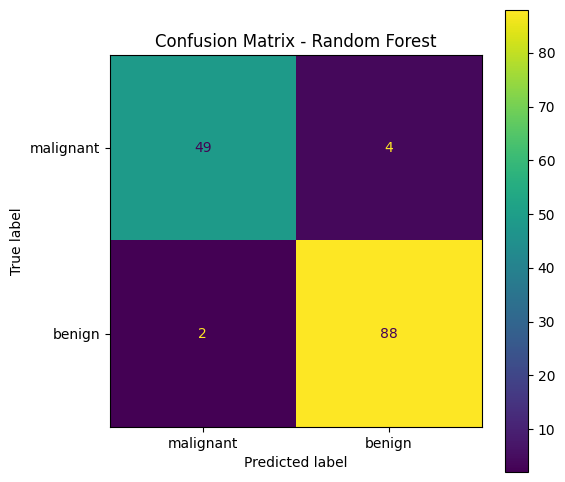

In [ ]:
# Select best model
if best_model_name == "Decision Tree":
    final_model = best_dt_model

elif best_model_name == "Random Forest":
    final_model = best_rf_model

else:
    final_model = best_gbm_model

# Predictions
y_final_pred = final_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_final_pred))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(ax=ax)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# **Final Model Comparison & Conclusio**n

## Best Model Results
- Decision Tree: **0.9441**
- Random Forest: **0.958**
- Gradient Boosting: **0.958**

## Overall Insight
- Both **Random Forest and GBM tied for the best performance (0.958)**.
- Decision Tree performed well but was clearly weaker due to limited model complexity.

## Key Takeaways
- Ensemble methods significantly outperform single Decision Trees.
- Random Forest provides **stable, consistent performance** across parameter changes.
- GBM achieves similar accuracy but is more sensitive to hyperparameters.
- The dataset is relatively well-structured, allowing high accuracy even with moderate tuning.

## Final Conclusion
Random Forest and Gradient Boosting are both optimal choices for this dataset, achieving the highest predictive performance while maintaining strong generalization. Decision Trees serve as a good baseline but are not sufficient alone for best results.